In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

In [3]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.5 MB/s eta 0:00:40
   ---------------------------------------- 1.0/100.2 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 1.6/100.2 MB 2.2 MB/s eta 0:00:45
    --------------------------------------- 2.1/100.2 MB 2.1 MB/s eta 0:00:48
   - -------------------------------------- 2.9/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.4/100.2 MB 2.4 MB/s eta 0:00:40
   - -------------------------------------- 3.7/100.2 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 4.2/100.2 MB 2.2 MB/s eta 0:00:43
   - -------------------------------------- 4.7/100.2 MB 2.3 MB/s eta 0:00:42
   -- ------------------------------------- 5.5/100.2 MB 2.4 MB/s eta 0:00:40
   -- -

In [7]:
import importlib.util

for lib in ["catboost", "lightgbm", "xgboost"]:
    print(lib, ":", "INSTALLED" if importlib.util.find_spec(lib) else "NOT INSTALLED")

catboost : INSTALLED
lightgbm : INSTALLED
xgboost : NOT INSTALLED


In [8]:
train = pd.read_csv("train.csv")

In [9]:
test = pd.read_csv("test.csv")

In [11]:
# Target
train["target"] = (train["Will_Buy_EV"] == "Yes").astype(int)

# Separate target
y = train["target"]

# Same folds will be used by every model
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = np.zeros(len(train), dtype=int)

for fold, (_, val_idx) in enumerate(skf.split(train, y)):
    folds[val_idx] = fold

print("Fold distribution:")
print(pd.Series(folds).value_counts().sort_index())

print("\nOverall positive rate:", y.mean())

for fold in range(5):
    print(
        f"Fold {fold}:",
        "train =", (folds != fold).sum(),
        "validation =", (folds == fold).sum(),
        "positive rate =",
        y[folds == fold].mean()
    )

Fold distribution:
0    133733
1    133733
2    133733
3    133733
4    133733
Name: count, dtype: int64

Overall positive rate: 0.17464500160768098
Fold 0: train = 534932 validation = 133733 positive rate = 0.17463901953893204
Fold 1: train = 534932 validation = 133733 positive rate = 0.1746464971248682
Fold 2: train = 534932 validation = 133733 positive rate = 0.1746464971248682
Fold 3: train = 534932 validation = 133733 positive rate = 0.1746464971248682
Fold 4: train = 534932 validation = 133733 positive rate = 0.1746464971248682


In [14]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

# Features
drop_cols = ["Will_Buy_EV", "target", "id"]

X = train.drop(columns=drop_cols)
y = train["target"]

# Categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(cat_cols)

print("\nFeatures:")
print(X.columns.tolist())

# OOF predictions
oof_cat = np.zeros(len(train))

# Test predictions
test_cat = np.zeros(len(test))

for fold in range(5):

    print(f"\n========== FOLD {fold} ==========")

    train_idx = np.where(folds != fold)[0]
    val_idx = np.where(folds == fold)[0]

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1500,
        learning_rate=0.05,
        depth=8,
        loss_function="Logloss",
        eval_metric="AUC",
        cat_features=cat_cols,
        random_seed=42,
        verbose=200,
        thread_count=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100
    )

    # Validation prediction
    val_pred = model.predict_proba(X_val)[:, 1]
    oof_cat[val_idx] = val_pred

    fold_auc = roc_auc_score(y_val, val_pred)

    print(f"Fold {fold} AUC: {fold_auc:.6f}")

    # Test prediction
    test_X = test.drop(columns=["id"])
    test_pred = model.predict_proba(test_X)[:, 1]

    test_cat += test_pred / 5

# Overall OOF score
cat_auc = roc_auc_score(y, oof_cat)

print("\n==============================")
print(f"CatBoost OOF ROC-AUC: {cat_auc:.6f}")
print("==============================")

Categorical columns:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

Features:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

========== FOLD 0 ==========
0:	test: 0.9314645	best: 0.9314645 (0)	total: 777ms	remaining: 19m 25s
200:	test: 0.9392664	best: 0.9392664 (200)	total: 2m 12s	remaining: 14m 16s
400:	test: 0.9399995	best: 0.9399995 (400)	total: 4m 8s	remaining: 11m 20s
600:	test: 0.9402979	best: 0.9402979 (600)	total: 6m 11s	remaining: 9m 16s
800:	test: 0.9404149	best: 0.9404150 (799)	total: 8m 10s	remaining: 7m 7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9404367617
bestIteration = 864

Shrink model to first 865 iterations.
Fold 0 AUC: 0.940437

========== FO

In [ ]:
np.save("/kaggle/working/oof_cat.npy", oof_cat)
np.save("/kaggle/working/test_cat.npy", test_cat)

In [1]:
pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 15.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import lightgbm as lgb

In [12]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import numpy as np

drop_cols = ["Will_Buy_EV", "target", "id"]

X = train.drop(columns=drop_cols).copy()
y = train["target"]

# Convert categorical columns to pandas category
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype("category")

X_test = test.drop(columns=["id"]).copy()

for col in cat_cols:
    X_test[col] = X_test[col].astype("category")

oof_lgb = np.zeros(len(train))
test_lgb = np.zeros(len(test))

for fold in range(5):

    print(f"\n========== FOLD {fold} ==========")

    train_idx = np.where(folds != fold)[0]
    val_idx = np.where(folds == fold)[0]

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        objective="binary",
        metric="auc",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(200)
        ]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_lgb[val_idx] = val_pred

    fold_auc = roc_auc_score(y_val, val_pred)
    print(f"Fold {fold} AUC: {fold_auc:.6f}")

    test_pred = model.predict_proba(X_test)[:, 1]
    test_lgb += test_pred / 5


lgb_auc = roc_auc_score(y, oof_lgb)

print("\n==============================")
print(f"LightGBM OOF ROC-AUC: {lgb_auc:.6f}")
print("==============================")


========== FOLD 0 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.939657
[400]	valid_0's auc: 0.940225
[600]	valid_0's auc: 0.94039
[800]	valid_0's auc: 0.940474
[1000]	valid_0's auc: 0.940552
[1200]	valid_0's auc: 0.940576
[1400]	valid_0's auc: 0.940586
Early stopping, best iteration is:
[1449]	valid_0's auc: 0.9406
Fold 0 AUC: 0.940600

========== FOLD 1 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.94082
[400]	valid_0's auc: 0.941282
[600]	valid_0's auc: 0.941416
[800]	valid_0's auc: 0.941482
[1000]	valid_0's auc: 0.941566
[1200]	valid_0's auc: 0.941587
Early stopping, best iteration is:
[1292]	valid_0's auc: 0.9416
Fold 1 AUC: 0.941600

========== FOLD 2 ==========


...

Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.942117
[400]	valid_0's auc: 0.942651
[600]	valid_0's auc: 0.942794
[800]	valid_0's auc: 0.942863
[1000]	valid_0's auc: 0.942892
[1200]	valid_0's auc: 0.942911
Early stopping, best iteration is:
[1161]	valid_0's auc: 0.942918
Fold 2 AUC: 0.942918

========== FOLD 3 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.941581
[400]	valid_0's auc: 0.94209
[600]	valid_0's auc: 0.942295
[800]	valid_0's auc: 0.942329
[1000]	valid_0's auc: 0.942339
Early stopping, best iteration is:
[922]	valid_0's auc: 0.94235
Fold 3 AUC: 0.942350

========== FOLD 4 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.940992
[400]	valid_0's auc: 0.94158
[600]	valid_0's auc: 0.941705
[800]	valid_0's auc: 0.941742
Early stopping, best iteration is:
[720]	valid_0's auc: 0.941753
Fold 4 AUC: 0.941753

LightGBM OOF ROC-AUC: 0.941832


In [17]:
from pathlib import Path

ARTIFACT_DIR = Path("ev_kaggle_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print(ARTIFACT_DIR.resolve())

C:\Users\Garv\Stats & Data Engineering\KAGGLE\ev_kaggle_artifacts


In [34]:
np.save(ARTIFACT_DIR / "oof_cat.npy", oof_cat)
np.save(ARTIFACT_DIR / "test_cat.npy", test_cat)

In [35]:
from sklearn.metrics import roc_auc_score

print("CatBoost:", roc_auc_score(y, oof_cat))
print("LightGBM:", roc_auc_score(y, oof_lgb))

CatBoost: 0.9415816807513815
LightGBM: 0.9418317605389006


In [36]:
pd.DataFrame({
    "id": train["id"],
    "target": y,
    "cat_oof": oof_cat
}).to_csv(ARTIFACT_DIR / "catboost_oof.csv", index=False)

pd.DataFrame({
    "id": test["id"],
    "cat_test": test_cat
}).to_csv(ARTIFACT_DIR / "catboost_test.csv", index=False)

In [37]:
model.save_model(
    str(ARTIFACT_DIR / f"catboost_fold_{fold}.cbm")
)

In [38]:
pd.DataFrame({
    "id": train["id"],
    "target": y,
    "lgb_oof": oof_lgb
}).to_csv(ARTIFACT_DIR / "lightgbm_oof.csv", index=False)

pd.DataFrame({
    "id": test["id"],
    "lgb_test": test_lgb
}).to_csv(ARTIFACT_DIR / "lightgbm_test.csv", index=False)

In [23]:
# final run

In [40]:
print("CatBoost OOF shape:", oof_cat.shape)
print("CatBoost test shape:", test_cat.shape)

CatBoost OOF shape: (668665,)
CatBoost test shape: (286571,)


In [41]:
from sklearn.metrics import roc_auc_score

print("CatBoost OOF AUC:", roc_auc_score(y, oof_cat))

CatBoost OOF AUC: 0.9415816807513815


In [42]:
from pathlib import Path

print("Files in artifact folder:\n")

for f in ARTIFACT_DIR.iterdir():
    print(f.name)

Files in artifact folder:

catboost_fold_4.cbm
catboost_oof.csv
catboost_test.csv
lightgbm_oof.csv
lightgbm_test.csv
oof_cat.npy
test_cat.npy


In [43]:
np.save(ARTIFACT_DIR / "oof_lgb.npy", oof_lgb)
np.save(ARTIFACT_DIR / "test_lgb.npy", test_lgb)

In [45]:
from pathlib import Path
import numpy as np
import pandas as pd

oof_cat = np.load(ARTIFACT_DIR / "oof_cat.npy")
test_cat = np.load(ARTIFACT_DIR / "test_cat.npy")

oof_lgb = np.load(ARTIFACT_DIR / "oof_lgb.npy")
test_lgb = np.load(ARTIFACT_DIR / "test_lgb.npy")

In [46]:
from pathlib import Path

ARTIFACT_DIR = Path(r"C:\Users\Garv\Stats & Data Engineering\KAGGLE\ev_kaggle_artifacts")

print("Folder exists:", ARTIFACT_DIR.exists())
print("\nFiles found:")

if ARTIFACT_DIR.exists():
    for f in ARTIFACT_DIR.iterdir():
        print(f.name)

Folder exists: True

Files found:
catboost_fold_4.cbm
catboost_oof.csv
catboost_test.csv
lightgbm_oof.csv
lightgbm_test.csv
oof_cat.npy
oof_lgb.npy
test_cat.npy
test_lgb.npy


In [47]:
np.save(ARTIFACT_DIR / "oof_lgb.npy", oof_lgb)
np.save(ARTIFACT_DIR / "test_lgb.npy", test_lgb)

print("LightGBM predictions saved successfully.")

LightGBM predictions saved successfully.


In [48]:
from sklearn.metrics import roc_auc_score

print("CatBoost OOF AUC :", roc_auc_score(y, oof_cat))
print("LightGBM OOF AUC :", roc_auc_score(y, oof_lgb))

CatBoost OOF AUC : 0.9415816807513815
LightGBM OOF AUC : 0.9418317605389006


In [49]:
blend_50 = 0.5 * oof_cat + 0.5 * oof_lgb

blend_auc = roc_auc_score(y, blend_50)

print(f"50/50 Blend AUC: {blend_auc:.6f}")

50/50 Blend AUC: 0.941874


In [50]:
corr = np.corrcoef(oof_cat, oof_lgb)[0, 1]

print(f"Prediction correlation: {corr:.6f}")

Prediction correlation: 0.997506


In [51]:
import pandas as pd
import numpy as np

# Start from raw features
X_fe = train.drop(columns=["Will_Buy_EV", "target", "id"]).copy()
X_test_fe = test.drop(columns=["id"]).copy()

# ------------------------------------------------
# 1. Core categorical interactions
# ------------------------------------------------

X_fe["Subsidy_Environmental"] = (
    X_fe["Subsidy_Available"].astype(str)
    + "_" +
    X_fe["Environmental_Concern_Level"].astype(str)
)

X_test_fe["Subsidy_Environmental"] = (
    X_test_fe["Subsidy_Available"].astype(str)
    + "_" +
    X_test_fe["Environmental_Concern_Level"].astype(str)
)


X_fe["Subsidy_RangeAnxiety"] = (
    X_fe["Subsidy_Available"].astype(str)
    + "_" +
    X_fe["Range_Anxiety_Level"].astype(str)
)

X_test_fe["Subsidy_RangeAnxiety"] = (
    X_test_fe["Subsidy_Available"].astype(str)
    + "_" +
    X_test_fe["Range_Anxiety_Level"].astype(str)
)


X_fe["Environmental_RangeAnxiety"] = (
    X_fe["Environmental_Concern_Level"].astype(str)
    + "_" +
    X_fe["Range_Anxiety_Level"].astype(str)
)

X_test_fe["Environmental_RangeAnxiety"] = (
    X_test_fe["Environmental_Concern_Level"].astype(str)
    + "_" +
    X_test_fe["Range_Anxiety_Level"].astype(str)
)


X_fe["Subsidy_HomeCharging"] = (
    X_fe["Subsidy_Available"].astype(str)
    + "_" +
    X_fe["Home_Charging_Possible"].astype(str)
)

X_test_fe["Subsidy_HomeCharging"] = (
    X_test_fe["Subsidy_Available"].astype(str)
    + "_" +
    X_test_fe["Home_Charging_Possible"].astype(str)
)

# ------------------------------------------------
# 2. Numeric interactions
# ------------------------------------------------

X_fe["Income_Environmental"] = (
    X_fe["Annual_Income_USD"]
    * X_fe["Environmental_Concern_Level"]
)

X_test_fe["Income_Environmental"] = (
    X_test_fe["Annual_Income_USD"]
    * X_test_fe["Environmental_Concern_Level"]
)


X_fe["Income_Environmental_Scaled"] = (
    X_fe["Annual_Income_USD"] / 100000
    * X_fe["Environmental_Concern_Level"]
)

X_test_fe["Income_Environmental_Scaled"] = (
    X_test_fe["Annual_Income_USD"] / 100000
    * X_test_fe["Environmental_Concern_Level"]
)


X_fe["Commute_ChargingHome"] = (
    X_fe["Daily_Commute_km"]
    * (X_fe["Charging_Stations_Near_Home"] + 1)
)

X_test_fe["Commute_ChargingHome"] = (
    X_test_fe["Daily_Commute_km"]
    * (X_test_fe["Charging_Stations_Near_Home"] + 1)
)

print("Original features:", 13)
print("New features:", len(X_fe.columns))
print(X_fe.columns.tolist())

Original features: 13
New features: 20
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Subsidy_Environmental', 'Subsidy_RangeAnxiety', 'Environmental_RangeAnxiety', 'Subsidy_HomeCharging', 'Income_Environmental', 'Income_Environmental_Scaled', 'Commute_ChargingHome']


In [52]:
cat_cols_fe = X_fe.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols_fe:
    X_fe[col] = X_fe[col].astype("category")
    X_test_fe[col] = X_test_fe[col].astype("category")

print("Categorical features:")
print(cat_cols_fe)

Categorical features:
['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Subsidy_Environmental', 'Subsidy_RangeAnxiety', 'Environmental_RangeAnxiety', 'Subsidy_HomeCharging']


In [53]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

oof_lgb_fe = np.zeros(len(train))
test_lgb_fe = np.zeros(len(test))

for fold in range(5):

    print(f"\n========== FOLD {fold} ==========")

    train_idx = np.where(folds != fold)[0]
    val_idx = np.where(folds == fold)[0]

    X_train = X_fe.iloc[train_idx]
    X_val = X_fe.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        objective="binary",
        metric="auc",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        categorical_feature=cat_cols_fe,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(200)
        ]
    )

    val_pred = model.predict_proba(X_val)[:, 1]

    oof_lgb_fe[val_idx] = val_pred

    fold_auc = roc_auc_score(y_val, val_pred)

    print(f"Fold {fold} AUC: {fold_auc:.6f}")

    test_pred = model.predict_proba(X_test_fe)[:, 1]

    test_lgb_fe += test_pred / 5


lgb_fe_auc = roc_auc_score(y, oof_lgb_fe)

print("\n==============================")
print(f"LightGBM + interactions OOF ROC-AUC: {lgb_fe_auc:.6f}")
print("==============================")


========== FOLD 0 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.93943
[400]	valid_0's auc: 0.940143
[600]	valid_0's auc: 0.940367
[800]	valid_0's auc: 0.940498
[1000]	valid_0's auc: 0.940545
[1200]	valid_0's auc: 0.940568
Early stopping, best iteration is:
[1156]	valid_0's auc: 0.940581
Fold 0 AUC: 0.940581

========== FOLD 1 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.940634
[400]	valid_0's auc: 0.941269
[600]	valid_0's auc: 0.941415
[800]	valid_0's auc: 0.941499
Early stopping, best iteration is:
[881]	valid_0's auc: 0.941529
Fold 1 AUC: 0.941529

========== FOLD 2 ==========


...

Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.941994
[400]	valid_0's auc: 0.942606
[600]	valid_0's auc: 0.94277
[800]	valid_0's auc: 0.94285
Early stopping, best iteration is:
[896]	valid_0's auc: 0.942879
Fold 2 AUC: 0.942879

========== FOLD 3 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.941465
[400]	valid_0's auc: 0.942072
[600]	valid_0's auc: 0.942298
Early stopping, best iteration is:
[639]	valid_0's auc: 0.942327
Fold 3 AUC: 0.942327

========== FOLD 4 ==========


C:\Users\Garv\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.940819
[400]	valid_0's auc: 0.941475
[600]	valid_0's auc: 0.941636
[800]	valid_0's auc: 0.941736
[1000]	valid_0's auc: 0.941821
Early stopping, best iteration is:
[1013]	valid_0's auc: 0.941823
Fold 4 AUC: 0.941823

LightGBM + interactions OOF ROC-AUC: 0.941813


In [54]:
X_score = train.drop(columns=["Will_Buy_EV", "target", "id"]).copy()
X_test_score = test.drop(columns=["id"]).copy()

# Convert categorical variables to numerical representations
subsidy = (X_score["Subsidy_Available"] == "Yes").astype(int)
env = X_score["Environmental_Concern_Level"]
income = X_score["Annual_Income_USD"] / 100000

range_score = X_score["Range_Anxiety_Level"].map({
    "Low": 0,
    "Medium": -1,
    "High": -3
})

X_score["structured_score"] = (
    1.2 * income
    + 0.6 * env
    + 2.0 * subsidy
    + range_score
)

# Test
subsidy_test = (X_test_score["Subsidy_Available"] == "Yes").astype(int)
env_test = X_test_score["Environmental_Concern_Level"]
income_test = X_test_score["Annual_Income_USD"] / 100000

range_score_test = X_test_score["Range_Anxiety_Level"].map({
    "Low": 0,
    "Medium": -1,
    "High": -3
})

X_test_score["structured_score"] = (
    1.2 * income_test
    + 0.6 * env_test
    + 2.0 * subsidy_test
    + range_score_test
)

In [55]:
from sklearn.metrics import roc_auc_score

score_auc = roc_auc_score(
    y,
    X_score["structured_score"]
)

print(f"Structured score AUC: {score_auc:.6f}")

Structured score AUC: 0.937690


In [56]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

X_lr = train.drop(columns=["Will_Buy_EV", "target", "id"])
y_lr = train["target"]

categorical_cols = X_lr.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_lr.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver="lbfgs"
    ))
])

In [57]:
oof_lr = np.zeros(len(train))

for fold in range(5):

    print(f"\n========== FOLD {fold} ==========")

    train_idx = np.where(folds != fold)[0]
    val_idx = np.where(folds == fold)[0]

    X_train = X_lr.iloc[train_idx]
    X_val = X_lr.iloc[val_idx]

    y_train = y_lr.iloc[train_idx]
    y_val = y_lr.iloc[val_idx]

    lr.fit(X_train, y_train)

    val_pred = lr.predict_proba(X_val)[:, 1]

    oof_lr[val_idx] = val_pred

    fold_auc = roc_auc_score(y_val, val_pred)

    print(f"Fold {fold} AUC: {fold_auc:.6f}")

lr_auc = roc_auc_score(y_lr, oof_lr)

print("\n==============================")
print(f"Logistic Regression OOF ROC-AUC: {lr_auc:.6f}")
print("==============================")


========== FOLD 0 ==========
Fold 0 AUC: 0.936669

========== FOLD 1 ==========
Fold 1 AUC: 0.938045

========== FOLD 2 ==========
Fold 2 AUC: 0.939071

========== FOLD 3 ==========
Fold 3 AUC: 0.938625

========== FOLD 4 ==========
Fold 4 AUC: 0.938067

Logistic Regression OOF ROC-AUC: 0.938094


In [58]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   - -------------------------------------- 2.1/48.9 MB 21.0 MB/s eta 0:00:03
   ------ --------------------------------- 8.1/48.9 MB 25.7 MB/s eta 0:00:02
   ----------- ---------------------------- 14.2/48.9 MB 26.2 MB/s eta 0:00:02
   ----------------- ---------------------- 22.0/48.9 MB 29.2 MB/s eta 0:00:01
   ----------------------- ---------------- 28.8/48.9 MB 30.1 MB/s eta 0:00:01
   ---------------------------- ----------- 34.9/48.9 MB 29.9 MB/s eta 0:00:01
   ---------------------------------- ----- 42.5/48.9 MB 31.0 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 31.6 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 29.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [59]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

print("XGBoost version:", xgb.__version__)

X_xgb = train.drop(columns=["Will_Buy_EV", "target", "id"]).copy()
y_xgb = train["target"].copy()

categorical_cols = X_xgb.select_dtypes(include=["object"]).columns.tolist()

# One-hot encode categoricals
X_xgb = pd.get_dummies(
    X_xgb,
    columns=categorical_cols,
    drop_first=False,
    dtype=np.float32
)

# Convert remaining numerical columns to float32
X_xgb = X_xgb.astype(np.float32)

print("XGBoost feature matrix:", X_xgb.shape)
print("Memory usage:", round(X_xgb.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

XGBoost version: 3.4.1
XGBoost feature matrix: (668665, 24)
Memory usage: 61.22 MB


In [60]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

oof_xgb = np.zeros(len(train), dtype=np.float32)
test_xgb = np.zeros(len(test), dtype=np.float32)

# Prepare test data using exactly the same encoding
X_test_xgb = test.drop(columns=["id"]).copy()

test_categorical_cols = X_test_xgb.select_dtypes(include=["object"]).columns.tolist()

X_test_xgb = pd.get_dummies(
    X_test_xgb,
    columns=test_categorical_cols,
    drop_first=False,
    dtype=np.float32
)

# Make sure train/test columns are identical
X_test_xgb = X_test_xgb.reindex(
    columns=X_xgb.columns,
    fill_value=0
).astype(np.float32)

print("Train:", X_xgb.shape)
print("Test :", X_test_xgb.shape)

for fold in range(5):

    print(f"\n========== FOLD {fold} ==========")

    train_idx = np.where(folds != fold)[0]
    val_idx = np.where(folds == fold)[0]

    X_train = X_xgb.iloc[train_idx]
    X_val = X_xgb.iloc[val_idx]

    y_train = y_xgb.iloc[train_idx]
    y_val = y_xgb.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        device="cpu",
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=100
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    test_pred = model.predict_proba(X_test_xgb)[:, 1]

    oof_xgb[val_idx] = val_pred
    test_xgb += test_pred / 5

    fold_auc = roc_auc_score(y_val, val_pred)

    print(f"Best iteration: {model.best_iteration}")
    print(f"Fold {fold} AUC: {fold_auc:.6f}")

xgb_auc = roc_auc_score(y_xgb, oof_xgb)

print("\n==============================")
print(f"XGBoost OOF ROC-AUC: {xgb_auc:.6f}")
print("==============================")

Train: (668665, 24)
Test : (286571, 24)

========== FOLD 0 ==========
Best iteration: 1042
Fold 0 AUC: 0.940635

========== FOLD 1 ==========
Best iteration: 802
Fold 1 AUC: 0.941669

========== FOLD 2 ==========
Best iteration: 775
Fold 2 AUC: 0.942839

========== FOLD 3 ==========
Best iteration: 796
Fold 3 AUC: 0.942450

========== FOLD 4 ==========
Best iteration: 779
Fold 4 AUC: 0.941842

XGBoost OOF ROC-AUC: 0.941876


In [61]:
np.save(ARTIFACT_DIR / "oof_xgb.npy", oof_xgb)
np.save(ARTIFACT_DIR / "test_xgb.npy", test_xgb)

print("XGBoost predictions saved.")

XGBoost predictions saved.


In [62]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Load if necessary
oof_cat = np.load(ARTIFACT_DIR / "oof_cat.npy")
oof_lgb = np.load(ARTIFACT_DIR / "oof_lgb.npy")
oof_xgb = np.load(ARTIFACT_DIR / "oof_xgb.npy")

print("Individual AUCs")
print("----------------")
print("CatBoost :", roc_auc_score(y, oof_cat))
print("LightGBM :", roc_auc_score(y, oof_lgb))
print("XGBoost  :", roc_auc_score(y, oof_xgb))

print("\nPrediction correlations")
print("-----------------------")

pred_df = pd.DataFrame({
    "CatBoost": oof_cat,
    "LightGBM": oof_lgb,
    "XGBoost": oof_xgb
})

print(pred_df.corr())

Individual AUCs
----------------
CatBoost : 0.9415816807513815
LightGBM : 0.9418317605389006
XGBoost  : 0.9418760513579997

Prediction correlations
-----------------------
          CatBoost  LightGBM   XGBoost
CatBoost  1.000000  0.997506  0.997916
LightGBM  0.997506  1.000000  0.997568
XGBoost   0.997916  0.997568  1.000000


In [63]:
blend_clx = (
    0.33 * oof_cat +
    0.33 * oof_lgb +
    0.34 * oof_xgb
)

blend_lx = (
    0.5 * oof_lgb +
    0.5 * oof_xgb
)

blend_cx = (
    0.5 * oof_cat +
    0.5 * oof_xgb
)

print("\nBlend results")
print("-------------")
print("Cat + LGB + XGB :", roc_auc_score(y, blend_clx))
print("LGB + XGB       :", roc_auc_score(y, blend_lx))
print("Cat + XGB       :", roc_auc_score(y, blend_cx))


Blend results
-------------
Cat + LGB + XGB : 0.9419652101917463
LGB + XGB       : 0.9420026857448622
Cat + XGB       : 0.9418652001142638


In [64]:
oof_lgb_xgb = 0.5 * oof_lgb + 0.5 * oof_xgb

np.save(
    ARTIFACT_DIR / "oof_lgb_xgb_50_50.npy",
    oof_lgb_xgb
)

test_lgb_xgb = 0.5 * test_lgb + 0.5 * test_xgb

np.save(
    ARTIFACT_DIR / "test_lgb_xgb_50_50.npy",
    test_lgb_xgb
)

print("Saved LGB + XGB blend.")

Saved LGB + XGB blend.


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [66]:
# ============================================================
# LOAD OOF PREDICTIONS
# ============================================================

oof_cat = np.load(ARTIFACT_DIR / "oof_cat.npy")
oof_lgb = np.load(ARTIFACT_DIR / "oof_lgb.npy")
oof_xgb = np.load(ARTIFACT_DIR / "oof_xgb.npy")

predictions = {
    "CatBoost": oof_cat,
    "LightGBM": oof_lgb,
    "XGBoost": oof_xgb
}

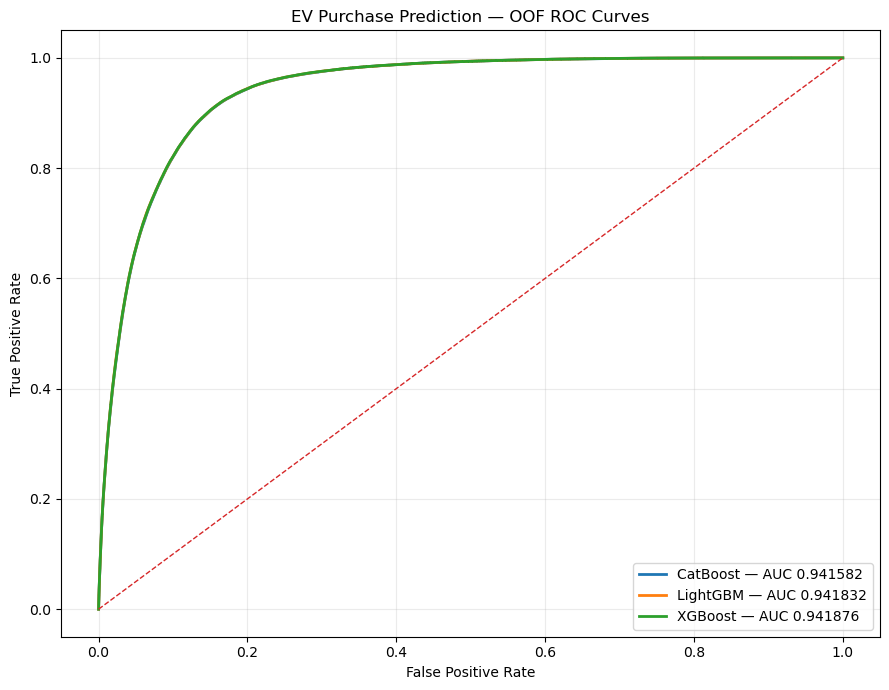

In [68]:
plt.figure(figsize=(9, 7))

for name, pred in predictions.items():

    fpr, tpr, _ = roc_curve(y, pred)
    auc = roc_auc_score(y, pred)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} — AUC {auc:.6f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EV Purchase Prediction — OOF ROC Curves")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

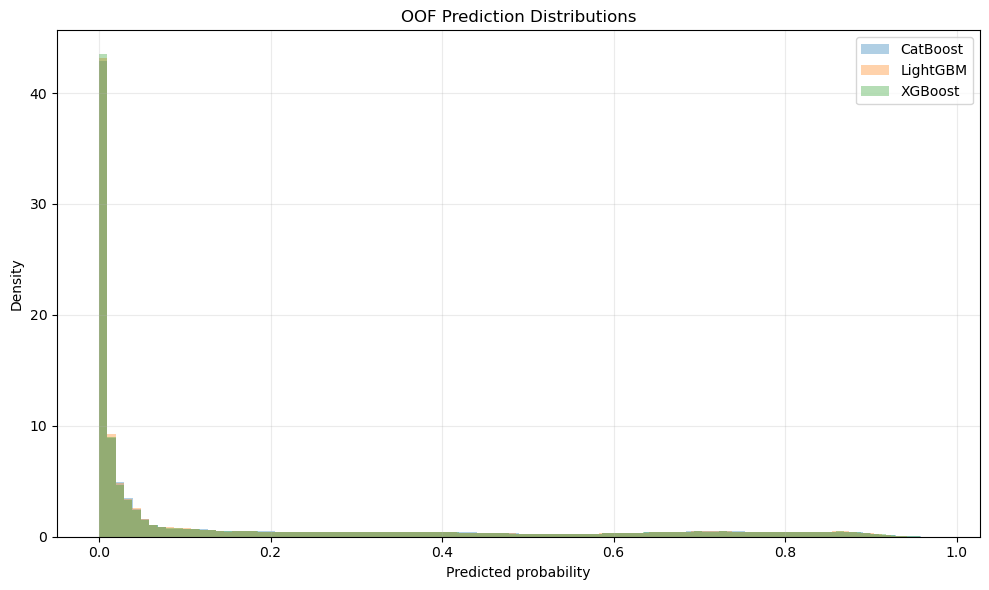

In [69]:

# ============================================================
# 2. PREDICTION DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(10, 6))

for name, pred in predictions.items():

    plt.hist(
        pred,
        bins=100,
        alpha=0.35,
        density=True,
        label=name
    )

plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("OOF Prediction Distributions")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [70]:
# ============================================================
# 3. CORRELATION MATRIX
# ============================================================

pred_df = pd.DataFrame(predictions)

correlation = pred_df.corr()

print("Prediction correlation matrix:")
display(correlation)


Prediction correlation matrix:


,CatBoost,LightGBM,XGBoost
CatBoost,1.000000,0.997506,0.997916
LightGBM,0.997506,1.000000,0.997568
XGBoost,0.997916,0.997568,1.000000


In [71]:
auc_df = pd.DataFrame({
    "Model": list(predictions.keys()),
    "OOF_AUC": [
        roc_auc_score(y, oof_cat),
        roc_auc_score(y, oof_lgb),
        roc_auc_score(y, oof_xgb)
    ]
})

display(auc_df)

,Model,OOF_AUC
0,CatBoost,0.941582
1,LightGBM,0.941832
2,XGBoost,0.941876


PHASE 2.5 -> FINDING LEAKAGE

In [72]:
# ============================================================
# LEAKAGE AUDIT — STEP 1
# ============================================================

print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE :", test.shape)

print("\nColumns in TRAIN:")
print(train.columns.tolist())

print("\nColumns in TEST:")
print(test.columns.tolist())

print("\nTarget:")
print(train["Will_Buy_EV"].value_counts(dropna=False))

print("\nPotential target-like columns:")

target_keywords = [
    "target",
    "buy",
    "purchase",
    "will",
    "label",
    "outcome",
    "decision",
    "probability",
    "score"
]

for col in train.columns:
    if any(word in col.lower() for word in target_keywords):
        print("  ⚠️", col)

TRAIN SHAPE: (668665, 16)
TEST SHAPE : (286571, 14)

Columns in TRAIN:
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV', 'target']

Columns in TEST:
['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

Target:
Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

Potential target-like columns:
  ⚠️ Will_Buy_EV
  ⚠️ target


In [73]:
# ============================================================
# ID LEAKAGE CHECK
# ============================================================

id_auc = roc_auc_score(
    train["target"],
    train["id"]
)

id_auc_reverse = roc_auc_score(
    train["target"],
    -train["id"]
)

print("AUC using ID directly:")
print("ID       :", id_auc)
print("-ID      :", id_auc_reverse)

AUC using ID directly:
ID       : 0.49998975839622495
-ID      : 0.5000102416037752


In [74]:
# ============================================================
# DUPLICATE FEATURE PATTERN CHECK
# ============================================================

feature_cols = [
    col for col in train.columns
    if col not in ["Will_Buy_EV", "target", "id"]
]

pattern_counts = (
    train
    .groupby(feature_cols, dropna=False)["target"]
    .agg(
        rows="size",
        positives="sum",
        positive_rate="mean"
    )
    .reset_index()
)

print("Total unique feature combinations:", len(pattern_counts))
print("Total training rows:", len(train))

print("\nFeature combinations with BOTH classes:")

mixed_patterns = pattern_counts[
    (pattern_counts["positives"] > 0) &
    (pattern_counts["positives"] < pattern_counts["rows"])
]

print("Mixed combinations:", len(mixed_patterns))
print(
    "Rows belonging to mixed combinations:",
    mixed_patterns["rows"].sum()
)

print("\nCompletely deterministic combinations:")

deterministic_patterns = pattern_counts[
    (pattern_counts["positives"] == 0) |
    (pattern_counts["positives"] == pattern_counts["rows"])
]

print(
    "Deterministic combinations:",
    len(deterministic_patterns)
)

print(
    "Rows belonging to deterministic combinations:",
    deterministic_patterns["rows"].sum()
)

Total unique feature combinations: 668665
Total training rows: 668665

Feature combinations with BOTH classes:
Mixed combinations: 0
Rows belonging to mixed combinations: 0

Completely deterministic combinations:
Deterministic combinations: 668665
Rows belonging to deterministic combinations: 668665


In [75]:
# ============================================================
# TARGET PURITY / STRUCTURE AUDIT
# ============================================================

def analyze_group(features):
    g = (
        train
        .groupby(features, dropna=False)["target"]
        .agg(
            rows="size",
            positives="sum",
            positive_rate="mean"
        )
        .reset_index()
    )

    # Weighted impurity: how mixed are the groups?
    # 0 = perfectly pure groups
    # Higher = more mixed
    p = g["positive_rate"]

    impurity = (
        2 * p * (1 - p) * g["rows"]
    ).sum() / len(train)

    # Fraction of rows in groups that are completely pure
    pure_rows = g.loc[
        (g["positive_rate"] == 0) |
        (g["positive_rate"] == 1),
        "rows"
    ].sum()

    print("\nFeatures:", features)
    print("Unique groups:", len(g))
    print("Pure groups:", (
        (g["positive_rate"] == 0) |
        (g["positive_rate"] == 1)
    ).sum())
    print("Rows in pure groups:", pure_rows)
    print("Fraction of rows in pure groups:", pure_rows / len(train))
    print("Weighted impurity:", impurity)

    print("\nLargest groups:")
    print(
        g.sort_values("rows", ascending=False)
         .head(10)
         .to_string(index=False)
    )

    return g


# ------------------------------------------------------------
# TEST PROGRESSIVELY STRONGER FEATURE COMBINATIONS
# ------------------------------------------------------------

groups_1 = analyze_group([
    "Subsidy_Available"
])

groups_2 = analyze_group([
    "Subsidy_Available",
    "Range_Anxiety_Level"
])

groups_3 = analyze_group([
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Environmental_Concern_Level"
])

groups_4 = analyze_group([
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Environmental_Concern_Level",
    "Home_Charging_Possible"
])


Features: ['Subsidy_Available']
Unique groups: 2
Pure groups: 0
Rows in pure groups: 0
Fraction of rows in pure groups: 0.0
Weighted impurity: 0.2544936122169633

Largest groups:
Subsidy_Available   rows  positives  positive_rate
              Yes 419909     115347       0.274695
               No 248756       1432       0.005757

Features: ['Subsidy_Available', 'Range_Anxiety_Level']
Unique groups: 6
Pure groups: 1
Rows in pure groups: 887
Fraction of rows in pure groups: 0.0013265237450741402
Weighted impurity: 0.24901022854875046

Largest groups:
Subsidy_Available Range_Anxiety_Level   rows  positives  positive_rate
              Yes                 Low 381386     112760       0.295658
               No                 Low 222586       1407       0.006321
              Yes              Medium  37216       2584       0.069433
               No              Medium  25283         25       0.000989
              Yes                High   1307          3       0.002295
               No

In [76]:
# ============================================================
# INCOME STRUCTURE INSIDE THE MAIN BEHAVIORAL GROUPS
# ============================================================

import pandas as pd
import numpy as np

# Main structural group
mask = (
    (train["Subsidy_Available"] == "Yes") &
    (train["Range_Anxiety_Level"] == "Low") &
    (train["Environmental_Concern_Level"] == 5)
)

subset = train.loc[
    mask,
    ["Annual_Income_USD", "target"]
].copy()

# Income deciles
subset["income_decile"] = pd.qcut(
    subset["Annual_Income_USD"],
    q=10,
    labels=False
)

income_table = (
    subset
    .groupby("income_decile")
    .agg(
        rows=("target", "size"),
        avg_income=("Annual_Income_USD", "mean"),
        purchase_rate=("target", "mean")
    )
)

income_table["purchase_rate"] *= 100

print("GROUP:")
print("Subsidy = Yes")
print("Range Anxiety = Low")
print("Environmental Concern = 5")

print("\nIncome decile analysis:")
print(income_table.round(4))

GROUP:
Subsidy = Yes
Range Anxiety = Low
Environmental Concern = 5

Income decile analysis:
               rows   avg_income  purchase_rate
income_decile                                  
0              8931   40172.7551        41.0144
1              8908   66222.0889        57.8244
2              9001   76334.4848        65.4261
3              8827   83521.5747        69.5480
4              8923   89786.5939        73.7644
5              8914   94853.8619        73.6818
6              8913  102697.9976        79.4121
7              8918  112048.3612        84.4696
8              8917  123490.6076        84.6697
9              8916  142539.2659        89.1095


In [77]:
# ============================================================
# INCOME EFFECT ACROSS ALL MAJOR STRUCTURAL GROUPS
# ============================================================

train["income_decile_global"] = pd.qcut(
    train["Annual_Income_USD"],
    q=10,
    labels=False
)

income_structure = (
    train
    .groupby(
        [
            "Subsidy_Available",
            "Range_Anxiety_Level",
            "Environmental_Concern_Level",
            "income_decile_global"
        ],
        observed=True
    )["target"]
    .agg(
        rows="size",
        purchase_rate="mean"
    )
    .reset_index()
)

income_structure["purchase_rate"] *= 100

# Only display reasonably large groups
income_structure = income_structure[
    income_structure["rows"] >= 1000
]

print(income_structure.to_string(index=False))

Subsidy_Available Range_Anxiety_Level  Environmental_Concern_Level  income_decile_global  rows  purchase_rate
               No                 Low                          1.0                     0  4741       0.000000
               No                 Low                          1.0                     1  5846       0.000000
               No                 Low                          1.0                     2  5649       0.000000
               No                 Low                          1.0                     3  5478       0.000000
               No                 Low                          1.0                     4  5417       0.036921
               No                 Low                          1.0                     5  5421       0.036894
               No                 Low                          1.0                     6  5363       0.018646
               No                 Low                          1.0                     7  5280       0.000000
          

In [82]:
# ============================================================
# EXPERIMENT: INCOME TRANSFORMATIONS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

tmp = train.copy()

# Raw income
tmp["income_raw"] = tmp["Annual_Income_USD"]

# Log income
tmp["income_log"] = np.log1p(tmp["Annual_Income_USD"])

# Global percentile/rank
tmp["income_rank"] = (
    tmp["Annual_Income_USD"]
    .rank(pct=True)
)

# Quantile bin
tmp["income_bin_20"] = pd.qcut(
    tmp["Annual_Income_USD"],
    q=20,
    labels=False,
    duplicates = "drop"
)

print(tmp[
    [
        "Annual_Income_USD",
        "income_log",
        "income_rank",
        "income_bin_20"
    ]
].head())

print("\nIncome transformation ranges:")
print(
    tmp[
        [
            "income_raw",
            "income_log",
            "income_rank",
            "income_bin_20"
        ]
    ].describe()
)

   Annual_Income_USD  income_log  income_rank  income_bin_20
0            92887.0   11.439150     0.627031             11
1            30000.0   10.308986     0.046066              0
2            94389.0   11.455190     0.652585             12
3            73580.0   11.206142     0.331567              5
4            57898.0   10.966455     0.158524              2

Income transformation ranges:
          income_raw     income_log    income_rank  income_bin_20
count  668665.000000  668665.000000  668665.000000  668665.000000
mean    84769.266989      11.277866       0.500001       8.547658
std     28648.029042       0.399812       0.288562       5.687373
min     30000.000000      10.308986       0.046066       0.000000
25%     67376.000000      11.118059       0.249994       3.000000
50%     84880.000000      11.349006       0.499994       8.000000
75%    102753.000000      11.540093       0.749988      13.000000
max    188549.000000      12.147119       1.000000      18.000000


In [84]:
# ============================================================
# INCOME RANK / BIN STRUCTURE
# ============================================================

rank_table = (
    tmp
    .groupby(
        ["main_group", "income_bin_20"],
        observed=True
    )["target"]
    .mean()
    .reset_index(name="purchase_rate")
)

rank_table["purchase_rate"] *= 100

# Display the most interesting structural groups
interesting_groups = [
    "Yes_Low_5.0",
    "Yes_Low_4.0",
    "Yes_Low_3.0",
    "No_Low_5.0",
    "No_Low_4.0",
    "No_Low_3.0"
]

result = rank_table[
    rank_table["main_group"].isin(interesting_groups)
]

print(result.to_string(index=False))

 main_group  income_bin_20  purchase_rate
 No_Low_3.0              0       0.063573
 No_Low_3.0              1       0.076307
 No_Low_3.0              2       0.160192
 No_Low_3.0              3       0.036127
 No_Low_3.0              4       0.442834
 No_Low_3.0              5       0.197161
 No_Low_3.0              6       0.322581
 No_Low_3.0              7       0.314589
 No_Low_3.0              8       0.200160
 No_Low_3.0              9       0.330306
 No_Low_3.0             10       0.238758
 No_Low_3.0             11       0.558419
 No_Low_3.0             12       0.212585
 No_Low_3.0             13       0.739130
 No_Low_3.0             14       0.265722
 No_Low_3.0             15       0.743310
 No_Low_3.0             16       0.591424
 No_Low_3.0             17       0.456853
 No_Low_3.0             18       0.934579
 No_Low_4.0              0       0.226012
 No_Low_4.0              1       0.358709
 No_Low_4.0              2       0.349786
 No_Low_4.0              3       0

In [85]:
# ============================================================
# OOF RESIDUAL / DISAGREEMENT ANALYSIS
# ============================================================

analysis = train.copy()

analysis["p_cat"] = oof_cat
analysis["p_lgb"] = oof_lgb
analysis["p_xgb"] = oof_xgb

# Current champion
analysis["p_blend"] = (
    0.5 * analysis["p_lgb"] +
    0.5 * analysis["p_xgb"]
)

# Absolute error
analysis["abs_error"] = (
    np.abs(analysis["target"] - analysis["p_blend"])
)

# Model disagreement
analysis["model_std"] = analysis[
    ["p_cat", "p_lgb", "p_xgb"]
].std(axis=1)

print("Overall mean absolute error:")
print(analysis["abs_error"].mean())

print("\nMean model disagreement:")
print(analysis["model_std"].mean())

Overall mean absolute error:
0.14244734302313636

Mean model disagreement:
0.006655825062400328


In [86]:
# ============================================================
# ERROR BY STRUCTURAL GROUP
# ============================================================

error_groups = (
    analysis
    .groupby(
        [
            "Subsidy_Available",
            "Range_Anxiety_Level",
            "Environmental_Concern_Level"
        ],
        observed=True
    )
    .agg(
        rows=("target", "size"),
        actual_rate=("target", "mean"),
        mean_prediction=("p_blend", "mean"),
        mean_abs_error=("abs_error", "mean"),
        mean_disagreement=("model_std", "mean")
    )
    .reset_index()
)

error_groups["actual_rate"] *= 100
error_groups["mean_prediction"] *= 100

print(
    error_groups
    .sort_values("mean_abs_error", ascending=False)
    .to_string(index=False)
)

Subsidy_Available Range_Anxiety_Level  Environmental_Concern_Level  rows  actual_rate  mean_prediction  mean_abs_error  mean_disagreement
              Yes                 Low                          4.0 73365    42.773802        42.799010        0.421156           0.017931
              Yes              Medium                          5.0  5376    28.478423        28.506019        0.355684           0.021898
              Yes                 Low                          5.0 89168    71.884533        71.843449        0.349173           0.015563
              Yes                 Low                          3.0 67522    20.236367        20.231544        0.293237           0.012701
              Yes              Medium                          4.0  6673    10.190319         9.908303        0.171360           0.010101
              Yes              Medium                          3.0  7061     4.291177         4.312139        0.080175           0.005733
              Yes                 

In [87]:
# ============================================================
# WITHIN-GROUP FEATURE AUC
# ============================================================

from sklearn.metrics import roc_auc_score

groups_to_test = {
    "Yes_Low_3": (
        (train["Subsidy_Available"] == "Yes") &
        (train["Range_Anxiety_Level"] == "Low") &
        (train["Environmental_Concern_Level"] == 3)
    ),
    
    "Yes_Low_4": (
        (train["Subsidy_Available"] == "Yes") &
        (train["Range_Anxiety_Level"] == "Low") &
        (train["Environmental_Concern_Level"] == 4)
    ),
    
    "Yes_Low_5": (
        (train["Subsidy_Available"] == "Yes") &
        (train["Range_Anxiety_Level"] == "Low") &
        (train["Environmental_Concern_Level"] == 5)
    )
}

numeric_features = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work"
]

for group_name, mask in groups_to_test.items():

    subset = train.loc[
        mask,
        numeric_features + ["target"]
    ]

    print("\n" + "=" * 60)
    print(group_name)
    print("Rows:", len(subset))
    print("Purchase rate:", subset["target"].mean())

    results = []

    for feature in numeric_features:

        x = subset[feature]
        y = subset["target"]

        auc = roc_auc_score(y, x)

        # Also check reverse direction
        auc_reverse = roc_auc_score(y, -x)

        best_auc = max(auc, auc_reverse)

        direction = (
            "positive"
            if auc >= auc_reverse
            else "negative"
        )

        results.append(
            (feature, best_auc, direction)
        )

    result_df = pd.DataFrame(
        results,
        columns=["feature", "AUC", "direction"]
    ).sort_values(
        "AUC",
        ascending=False
    )

    print(result_df.to_string(index=False))


Yes_Low_3
Rows: 67522
Purchase rate: 0.20236367406178726
                    feature      AUC direction
          Annual_Income_USD 0.685726  positive
Charging_Stations_Near_Work 0.516736  negative
Charging_Stations_Near_Home 0.512459  negative
           Daily_Commute_km 0.511491  negative
       Number_of_Cars_Owned 0.505313  positive
                        Age 0.502311  negative

Yes_Low_4
Rows: 73365
Purchase rate: 0.4277380222176787
                    feature      AUC direction
          Annual_Income_USD 0.688514  positive
           Daily_Commute_km 0.519766  negative
Charging_Stations_Near_Home 0.508177  negative
Charging_Stations_Near_Work 0.507843  negative
       Number_of_Cars_Owned 0.503621  positive
                        Age 0.503508  negative

Yes_Low_5
Rows: 89168
Purchase rate: 0.718845325677373
                    feature      AUC direction
          Annual_Income_USD 0.689207  positive
           Daily_Commute_km 0.519420  negative
       Number_of_Cars_Owned 0.

In [88]:
# ============================================================
# INCOME TRANSFORMATION AUC
# ============================================================

from sklearn.metrics import roc_auc_score
import numpy as np

y = train["target"]

income = train["Annual_Income_USD"]

income_features = {
    "raw_income": income,
    "log_income": np.log1p(income),
    "income_rank": income.rank(pct=True),
    "income_squared": income ** 2,
    "income_sqrt": np.sqrt(income)
}

print("GLOBAL INCOME TRANSFORMATIONS")
print("=" * 50)

for name, values in income_features.items():

    auc = roc_auc_score(y, values)

    # AUC direction
    auc = max(auc, 1 - auc)

    print(f"{name:20s} {auc:.6f}")

GLOBAL INCOME TRANSFORMATIONS
raw_income           0.670367
log_income           0.670367
income_rank          0.670367
income_squared       0.670367
income_sqrt          0.670367


In [89]:
# ============================================================
# WITHIN-GROUP INCOME TRANSFORMATIONS
# ============================================================

for group_name, mask in groups_to_test.items():

    subset = train.loc[
        mask,
        ["Annual_Income_USD", "target"]
    ]

    income = subset["Annual_Income_USD"]

    transformations = {
        "raw": income,
        "log": np.log1p(income),
        "rank": income.rank(pct=True),
        "sqrt": np.sqrt(income),
        "squared": income ** 2
    }

    print("\n" + "=" * 60)
    print(group_name)

    for name, values in transformations.items():

        auc = roc_auc_score(
            subset["target"],
            values
        )

        auc = max(auc, 1 - auc)

        print(f"{name:10s}: {auc:.6f}")


Yes_Low_3
raw       : 0.685726
log       : 0.685726
rank      : 0.685726
sqrt      : 0.685726
squared   : 0.685726

Yes_Low_4
raw       : 0.688514
log       : 0.688514
rank      : 0.688514
sqrt      : 0.688514
squared   : 0.688514

Yes_Low_5
raw       : 0.689207
log       : 0.689207
rank      : 0.689207
sqrt      : 0.689207
squared   : 0.689207


In [90]:
# ============================================================
# CONDITIONAL INCOME RANK
# ============================================================

from sklearn.metrics import roc_auc_score

group_cols = [
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Environmental_Concern_Level"
]

train["income_cond_rank"] = (
    train.groupby(group_cols)["Annual_Income_USD"]
         .rank(pct=True)
)

global_auc = roc_auc_score(
    train["target"],
    train["income_cond_rank"]
)

print("Global conditional-income AUC:", global_auc)

Global conditional-income AUC: 0.6050029445379682


In [91]:
for group_name, mask in groups_to_test.items():

    subset = train.loc[
        mask,
        ["income_cond_rank", "target"]
    ]

    auc = roc_auc_score(
        subset["target"],
        subset["income_cond_rank"]
    )

    print(f"{group_name}: {auc:.6f}")

Yes_Low_3: 0.685726
Yes_Low_4: 0.688514
Yes_Low_5: 0.689207


In [92]:
from sklearn.metrics import roc_auc_score

group_cols = [
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Environmental_Concern_Level"
]

results = []

for group_values, subset in train.groupby(group_cols):

    if subset["target"].nunique() < 2:
        continue

    auc = roc_auc_score(
        subset["target"],
        subset["Annual_Income_USD"]
    )

    auc = max(auc, 1 - auc)

    results.append({
        "Subsidy": group_values[0],
        "Range": group_values[1],
        "Env": group_values[2],
        "Rows": len(subset),
        "Purchase_Rate": subset["target"].mean(),
        "Income_AUC": auc
    })

income_group_auc = (
    pd.DataFrame(results)
    .sort_values("Income_AUC", ascending=False)
)

print(income_group_auc.to_string(index=False))

Subsidy  Range  Env  Rows  Purchase_Rate  Income_AUC
     No Medium  5.0  3498       0.004002    0.782649
    Yes   High  5.0   125       0.024000    0.729508
     No Medium  3.0  5068       0.000592    0.718987
     No    Low  1.0 53141       0.000169    0.718896
    Yes Medium  5.0  5376       0.284784    0.702321
     No Medium  4.0  4945       0.001416    0.702005
    Yes Medium  3.0  7061       0.042912    0.697387
    Yes    Low  2.0 73342       0.038286    0.693022
    Yes Medium  4.0  6673       0.101903    0.691294
     No    Low  5.0 29967       0.027263    0.690453
    Yes    Low  5.0 89168       0.718845    0.689207
    Yes    Low  4.0 73365       0.427738    0.688514
    Yes    Low  3.0 67522       0.202364    0.685726
    Yes Medium  1.0  9436       0.001590    0.679850
     No    Low  2.0 47136       0.000552    0.678836
    Yes    Low  1.0 77989       0.010373    0.672917
     No    Low  3.0 47262       0.003301    0.664718
     No    Low  4.0 45080       0.008851    0.

In [93]:
from sklearn.metrics import roc_auc_score

group_cols = [
    "Subsidy_Available",
    "Range_Anxiety_Level",
    "Environmental_Concern_Level"
]

results = []

for group_values, subset in train.groupby(group_cols):

    if subset["target"].nunique() < 2:
        continue

    auc = roc_auc_score(
        subset["target"],
        subset["Annual_Income_USD"]
    )

    auc = max(auc, 1 - auc)

    results.append({
        "Subsidy": group_values[0],
        "Range": group_values[1],
        "Env": group_values[2],
        "Rows": len(subset),
        "Purchase_Rate": subset["target"].mean(),
        "Income_AUC": auc
    })

income_group_auc = (
    pd.DataFrame(results)
    .sort_values("Income_AUC", ascending=False)
)

print(income_group_auc.to_string(index=False))

Subsidy  Range  Env  Rows  Purchase_Rate  Income_AUC
     No Medium  5.0  3498       0.004002    0.782649
    Yes   High  5.0   125       0.024000    0.729508
     No Medium  3.0  5068       0.000592    0.718987
     No    Low  1.0 53141       0.000169    0.718896
    Yes Medium  5.0  5376       0.284784    0.702321
     No Medium  4.0  4945       0.001416    0.702005
    Yes Medium  3.0  7061       0.042912    0.697387
    Yes    Low  2.0 73342       0.038286    0.693022
    Yes Medium  4.0  6673       0.101903    0.691294
     No    Low  5.0 29967       0.027263    0.690453
    Yes    Low  5.0 89168       0.718845    0.689207
    Yes    Low  4.0 73365       0.427738    0.688514
    Yes    Low  3.0 67522       0.202364    0.685726
    Yes Medium  1.0  9436       0.001590    0.679850
     No    Low  2.0 47136       0.000552    0.678836
    Yes    Low  1.0 77989       0.010373    0.672917
     No    Low  3.0 47262       0.003301    0.664718
     No    Low  4.0 45080       0.008851    0.

In [94]:
# ============================================================
# WITHIN-GROUP INCOME DECILE PURCHASE CURVES
# ============================================================

groups = {
    "Yes_Low_3": (
        (train["Subsidy_Available"] == "Yes") &
        (train["Range_Anxiety_Level"] == "Low") &
        (train["Environmental_Concern_Level"] == 3)
    ),
    "Yes_Low_4": (
        (train["Subsidy_Available"] == "Yes") &
        (train["Range_Anxiety_Level"] == "Low") &
        (train["Environmental_Concern_Level"] == 4)
    ),
    "Yes_Low_5": (
        (train["Subsidy_Available"] == "Yes") &
        (train["Range_Anxiety_Level"] == "Low") &
        (train["Environmental_Concern_Level"] == 5)
    )
}

for name, mask in groups.items():

    subset = train.loc[
        mask,
        ["Annual_Income_USD", "target"]
    ].copy()

    subset["income_decile"] = pd.qcut(
        subset["Annual_Income_USD"],
        q=10,
        labels=False,
        duplicates="drop"
    )

    curve = (
        subset
        .groupby("income_decile")
        .agg(
            rows=("target", "size"),
            avg_income=("Annual_Income_USD", "mean"),
            purchase_rate=("target", "mean")
        )
        .reset_index()
    )

    curve["purchase_rate_pct"] = curve["purchase_rate"] * 100

    print("\n" + "=" * 75)
    print(name)
    print(
        curve[
            [
                "income_decile",
                "rows",
                "avg_income",
                "purchase_rate_pct"
            ]
        ].to_string(index=False)
    )


Yes_Low_3
 income_decile  rows    avg_income  purchase_rate_pct
             0 13511  42530.167641           7.238546
             1  6746  66849.187667          11.043581
             2  6752  74921.241706          15.091825
             3  6775  82065.287528          17.712177
             4  6733  88195.606416          20.496064
             5  6750  94099.602370          23.481481
             6  6787 102238.622366          25.681450
             7  6723 115057.886063          34.597650
             8  6745 135252.813343          39.851742

Yes_Low_4
 income_decile  rows    avg_income  purchase_rate_pct
             0  7338  33207.244753          12.319433
             1  7339  59355.229050          23.027660
             2  7352  70491.861670          34.126768
             3  7321  78442.663980          38.519328
             4  7340  84922.720708          40.217984
             5  7341  91379.353494          45.225446
             6  7324  97302.656608          47.678864
      